In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/hassanamin/textdb3/fake_or_real_news.csv


In [2]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score
)

from xgboost import XGBClassifier

In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

df = pd.read_csv(
    "/kaggle/input/datasets/hassanamin/textdb3/fake_or_real_news.csv"
)



df = df.drop_duplicates(
    subset=["text"]
)

print(df.shape)

/kaggle/input/datasets/hassanamin/textdb3/fake_or_real_news.csv
(6060, 4)


In [4]:
X = df["text"].fillna("")
y = df["label"]

X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [5]:
tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,3),
    max_df=0.90,
    min_df=2,
    sublinear_tf=True,
    max_features=40000
)

X_train = tfidf.fit_transform(
    X_train_text
)

X_val = tfidf.transform(
    X_val_text
)

X_test = tfidf.transform(
    X_test_text
)

In [6]:
le = LabelEncoder()

y_train = le.fit_transform(
    y_train
)

y_val = le.transform(
    y_val
)

y_test = le.transform(
    y_test
)

In [7]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [8]:
pred = xgb.predict(
    X_test
)

prob = xgb.predict_proba(
    X_test
)[:,1]

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        pred
    )
)

print(
    classification_report(
        y_test,
        pred
    )
)

print(
    "ROC AUC:",
    roc_auc_score(
        y_test,
        prob
    )
)

Accuracy: 0.9185918591859186
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       461
           1       0.93      0.90      0.92       448

    accuracy                           0.92       909
   macro avg       0.92      0.92      0.92       909
weighted avg       0.92      0.92      0.92       909

ROC AUC: 0.976310718159281


In [9]:
from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, roc_auc_score

import pandas as pd

tfidf_params = {
    "ngram_range": [(1,1), (1,2), (1,3)],
    "max_features": [15000, 30000],
    "min_df": [1, 2],
    "max_df": [0.85, 0.9],
    "sublinear_tf": [True]
}

In [10]:
xgb_params = {
    "n_estimators": [300, 500],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05],
    "subsample": [0.7, 0.8],
    "colsample_bytree": [0.7, 0.8],
    "min_child_weight": [1, 3]
}

In [11]:
def run_xgb_experiment(tfidf_p, xgb_p):
    
    tfidf = TfidfVectorizer(
        stop_words="english",
        ngram_range=tfidf_p["ngram_range"],
        max_features=tfidf_p["max_features"],
        min_df=tfidf_p["min_df"],
        max_df=tfidf_p["max_df"],
        sublinear_tf=tfidf_p["sublinear_tf"]
    )
    
    X_train_vec = tfidf.fit_transform(X_train_text)
    X_test_vec = tfidf.transform(X_test_text)
    
    model = XGBClassifier(
        n_estimators=xgb_p["n_estimators"],
        max_depth=xgb_p["max_depth"],
        learning_rate=xgb_p["learning_rate"],
        subsample=xgb_p["subsample"],
        colsample_bytree=xgb_p["colsample_bytree"],
        min_child_weight=xgb_p["min_child_weight"],
        eval_metric="logloss",
        random_state=42
    )
    
    model.fit(X_train_vec, y_train)
    
    pred = model.predict(X_test_vec)
    prob = model.predict_proba(X_test_vec)[:,1]
    
    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, prob)
    
    return acc, auc

In [12]:
import random

results = []

tfidf_keys = list(tfidf_params.keys())
xgb_keys = list(xgb_params.keys())

for i in range(20):   # 20 smart experiments
    
    tfidf_p = {
        "ngram_range": random.choice(tfidf_params["ngram_range"]),
        "max_features": random.choice(tfidf_params["max_features"]),
        "min_df": random.choice(tfidf_params["min_df"]),
        "max_df": random.choice(tfidf_params["max_df"]),
        "sublinear_tf": random.choice(tfidf_params["sublinear_tf"])
    }
    
    xgb_p = {
        "n_estimators": random.choice(xgb_params["n_estimators"]),
        "max_depth": random.choice(xgb_params["max_depth"]),
        "learning_rate": random.choice(xgb_params["learning_rate"]),
        "subsample": random.choice(xgb_params["subsample"]),
        "colsample_bytree": random.choice(xgb_params["colsample_bytree"]),
        "min_child_weight": random.choice(xgb_params["min_child_weight"])
    }
    
    acc, auc = run_xgb_experiment(tfidf_p, xgb_p)
    
    results.append({
        **tfidf_p,
        **xgb_p,
        "accuracy": acc,
        "roc_auc": auc
    })
    
    print(f"Run {i+1}:", acc, auc)

Run 1: 0.922992299229923 0.9767682832352029
Run 2: 0.9240924092409241 0.9748702355128602
Run 3: 0.9295929592959296 0.9781433994422064
Run 4: 0.9240924092409241 0.9750832816857763
Run 5: 0.9185918591859186 0.9732215486519988
Run 6: 0.9218921892189219 0.9771653238301827
Run 7: 0.9042904290429042 0.9600490006197706
Run 8: 0.9031903190319032 0.9610658118995972
Run 9: 0.9196919691969196 0.9723911527734738
Run 10: 0.9240924092409241 0.9746935040285095
Run 11: 0.9240924092409241 0.9742553067864891
Run 12: 0.922992299229923 0.9684401146575767
Run 13: 0.9284928492849285 0.9744925627517819
Run 14: 0.9218921892189219 0.9719021149674621
Run 15: 0.922992299229923 0.9742746746203904
Run 16: 0.922992299229923 0.9734733304927178
Run 17: 0.922992299229923 0.9680406530833592
Run 18: 0.9207920792079208 0.9672538348311125
Run 19: 0.9174917491749175 0.9686483188720174
Run 20: 0.9207920792079208 0.9709627750232415


In [13]:
df_results = pd.DataFrame(results)

df_results = df_results.sort_values(
    by="roc_auc",
    ascending=False
)

df_results.head(10)

,ngram_range,max_features,min_df,max_df,sublinear_tf,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,accuracy,roc_auc
2,"(1, 3)",30000,2,0.85,True,500,7,0.05,0.8,0.8,1,0.929593,0.978143
5,"(1, 2)",30000,1,0.90,True,500,7,0.03,0.7,0.8,1,0.921892,0.977165
0,"(1, 3)",30000,1,0.90,True,500,5,0.05,0.8,0.7,1,0.922992,0.976768
3,"(1, 1)",30000,2,0.85,True,500,5,0.05,0.8,0.8,1,0.924092,0.975083
1,"(1, 2)",30000,2,0.90,True,300,7,0.05,0.7,0.8,3,0.924092,0.974870
9,"(1, 2)",30000,2,0.90,True,300,5,0.05,0.7,0.8,1,0.924092,0.974694
12,"(1, 3)",30000,2,0.90,True,500,3,0.05,0.7,0.8,1,0.928493,0.974493
14,"(1, 1)",15000,2,0.90,True,300,7,0.05,0.7,0.7,3,0.922992,0.974275
10,"(1, 1)",15000,2,0.90,True,500,5,0.03,0.7,0.8,1,0.924092,0.974255
15,"(1, 2)",15000,1,0.90,True,300,5,0.05,0.8,0.8,1,0.922992,0.973473


In [14]:
best = df_results.iloc[0]

print("BEST CONFIG:")
print(best)

BEST CONFIG:
ngram_range           (1, 3)
max_features           30000
min_df                     2
max_df                  0.85
sublinear_tf            True
n_estimators             500
max_depth                  7
learning_rate           0.05
subsample                0.8
colsample_bytree         0.8
min_child_weight           1
accuracy            0.929593
roc_auc             0.978143
Name: 2, dtype: object


In [15]:
pivot_table = df_results.pivot_table(
    values="accuracy",
    index="ngram_range",
    columns="max_features",
    aggfunc="mean"
)

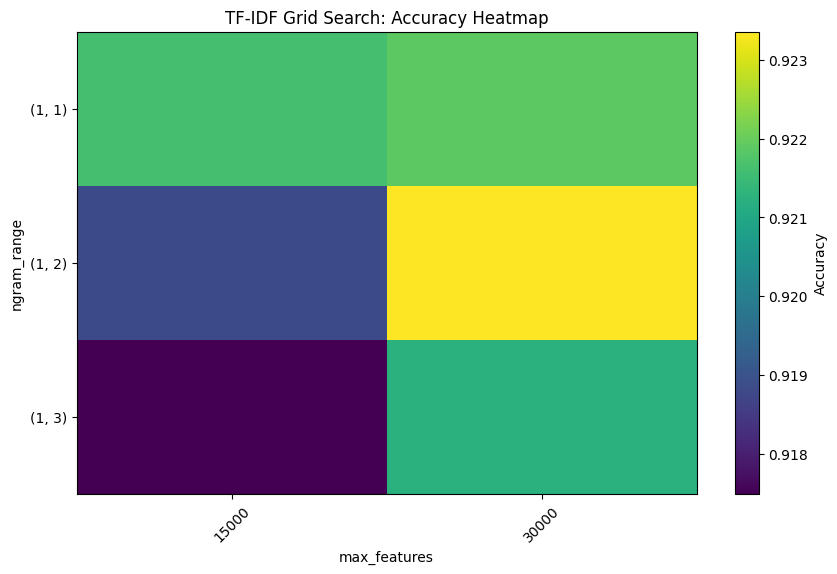

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.imshow(pivot_table, aspect="auto")

plt.colorbar(label="Accuracy")

plt.xticks(
    ticks=range(len(pivot_table.columns)),
    labels=pivot_table.columns,
    rotation=45
)

plt.yticks(
    ticks=range(len(pivot_table.index)),
    labels=pivot_table.index
)

plt.title("TF-IDF Grid Search: Accuracy Heatmap")
plt.xlabel("max_features")
plt.ylabel("ngram_range")

plt.show()

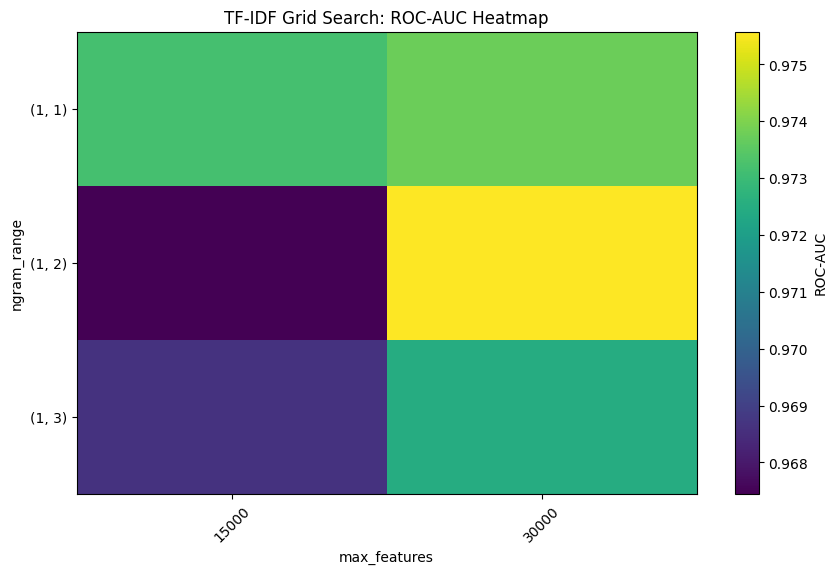

In [17]:
pivot_auc = df_results.pivot_table(
    values="roc_auc",
    index="ngram_range",
    columns="max_features",
    aggfunc="mean"
)

plt.figure(figsize=(10,6))

plt.imshow(pivot_auc, aspect="auto")
plt.colorbar(label="ROC-AUC")

plt.xticks(
    ticks=range(len(pivot_auc.columns)),
    labels=pivot_auc.columns,
    rotation=45
)

plt.yticks(
    ticks=range(len(pivot_auc.index)),
    labels=pivot_auc.index
)

plt.title("TF-IDF Grid Search: ROC-AUC Heatmap")
plt.xlabel("max_features")
plt.ylabel("ngram_range")

plt.show()

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import numpy as np

In [19]:
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("xgb", XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ))
])

In [20]:
param_dist = {
    
    # TF-IDF space
    "tfidf__ngram_range": [(1,1), (1,2), (1,3)],
    "tfidf__max_features": [15000, 30000, 50000],
    "tfidf__min_df": [1, 2, 3],
    "tfidf__max_df": [0.85, 0.9],
    "tfidf__sublinear_tf": [True, False],

    # XGBoost space
    "xgb__n_estimators": [300, 500, 700],
    "xgb__max_depth": [3, 5, 7],
    "xgb__learning_rate": [0.03, 0.05, 0.1],
    "xgb__subsample": [0.7, 0.8, 0.9],
    "xgb__colsample_bytree": [0.6, 0.7, 0.8],
    "xgb__min_child_weight": [1, 3, 5]
}

In [21]:
search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=20,          # increase to 50+ if you want stronger results
    scoring="accuracy",
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

In [22]:
search.fit(X_train_text, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('tfidf',
                                              TfidfVectorizer(stop_words='english')),
                                             ('xgb',
                                              XGBClassifier(base_score=None,
                                                            booster=None,
                                                            callbacks=None,
                                                            colsample_bylevel=None,
                                                            colsample_bynode=None,
                                                            colsample_bytree=None,
                                                            device=None,
                                                            early_stopping_rounds=None,
                                                            enable_categorical=False,
                                                            eval_metric='logloss',
                                                            feature_types=None,
                                                            feature_weights...
                                                                50000],
                                        'tfidf__min_df': [1, 2, 3],
                                        'tfidf__ngram_range': [(1, 1), (1, 2),
                                                               (1, 3)],
                                        'tfidf__sublinear_tf': [True, False],
                                        'xgb__colsample_bytree': [0.6, 0.7,
                                                                  0.8],
                                        'xgb__learning_rate': [0.03, 0.05, 0.1],
                                        'xgb__max_depth': [3, 5, 7],
                                        'xgb__min_child_weight': [1, 3, 5],
                                        'xgb__n_estimators': [300, 500, 700],
                                        'xgb__subsample': [0.7, 0.8, 0.9]},
                   random_state=42, scoring='accuracy', verbose=2)

In [23]:
print("Best Params:")
print(search.best_params_)

best_model = search.best_estimator_

Best Params:
{'xgb__subsample': 0.9, 'xgb__n_estimators': 700, 'xgb__min_child_weight': 3, 'xgb__max_depth': 5, 'xgb__learning_rate': 0.03, 'xgb__colsample_bytree': 0.6, 'tfidf__sublinear_tf': False, 'tfidf__ngram_range': (1, 3), 'tfidf__min_df': 3, 'tfidf__max_features': 30000, 'tfidf__max_df': 0.9}


In [24]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

pred = best_model.predict(X_test_text)
prob = best_model.predict_proba(X_test_text)[:,1]

print("Accuracy:", accuracy_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, prob))

print(classification_report(y_test, pred))

Accuracy: 0.9262926292629263
ROC-AUC: 0.9764148202665014
              precision    recall  f1-score   support

           0       0.91      0.94      0.93       461
           1       0.94      0.91      0.92       448

    accuracy                           0.93       909
   macro avg       0.93      0.93      0.93       909
weighted avg       0.93      0.93      0.93       909



In [25]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score

In [26]:
from xgboost import XGBClassifier

base_model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=1,
    eval_metric="logloss",
    random_state=42
)

In [27]:
calibrated_model = CalibratedClassifierCV(
    estimator=base_model,
    method="sigmoid",
    cv=3
)

In [28]:
calibrated_model.fit(
    X_train,
    y_train
)

prob = calibrated_model.predict_proba(
    X_test
)[:,1]

from sklearn.metrics import roc_auc_score

print(
    "Calibrated ROC:",
    roc_auc_score(
        y_test,
        prob
    )
)

[CV] END tfidf__max_df=0.85, tfidf__max_features=30000, tfidf__min_df=1, tfidf__ngram_range=(1, 2), tfidf__sublinear_tf=False, xgb__colsample_bytree=0.8, xgb__learning_rate=0.03, xgb__max_depth=3, xgb__min_child_weight=1, xgb__n_estimators=300, xgb__subsample=0.7; total time= 1.5min
[CV] END tfidf__max_df=0.9, tfidf__max_features=50000, tfidf__min_df=3, tfidf__ngram_range=(1, 2), tfidf__sublinear_tf=False, xgb__colsample_bytree=0.7, xgb__learning_rate=0.03, xgb__max_depth=5, xgb__min_child_weight=1, xgb__n_estimators=500, xgb__subsample=0.9; total time= 4.1min
[CV] END tfidf__max_df=0.9, tfidf__max_features=30000, tfidf__min_df=1, tfidf__ngram_range=(1, 2), tfidf__sublinear_tf=False, xgb__colsample_bytree=0.6, xgb__learning_rate=0.1, xgb__max_depth=5, xgb__min_child_weight=5, xgb__n_estimators=500, xgb__subsample=0.8; total time= 1.5min
[CV] END tfidf__max_df=0.85, tfidf__max_features=50000, tfidf__min_df=3, tfidf__ngram_range=(1, 2), tfidf__sublinear_tf=False, xgb__colsample_bytree=0.